# 放电参数图

## 80485放电参数图

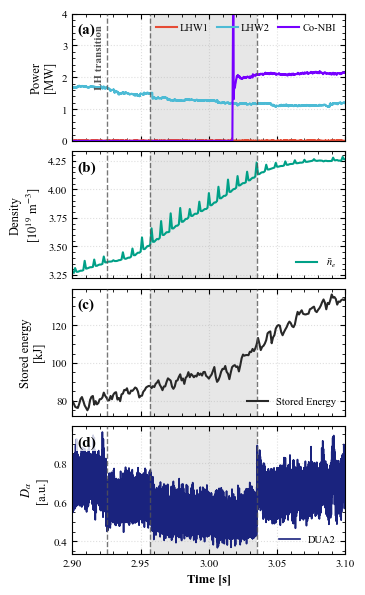

In [1]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
from spectrum_toolbox import MDSDataLoader

# ====================== 科研繪圖配置 (雙欄排版之單欄最佳化版) ======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],  
    'mathtext.fontset': 'stix',                  
    'axes.unicode_minus': False,                 
    'font.size': 9,                             # 基礎字號下調至 9pt，適合 3.5 吋寬度
    'axes.labelsize': 9,                        # 座標軸標籤字號
    'xtick.labelsize': 8,                       # 刻度字號下調至 8pt
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                     # 圖例字號調小，避免遮擋資料
    'xtick.direction': 'in',                    # 刻度朝內
    'ytick.direction': 'in',
    'xtick.top': True,                           
    'ytick.right': True,                         
    'axes.linewidth': 0.8                       # 外框線寬度稍微調細，避免在小圖中顯得笨重
})

# ====================== 參數設定 ======================
shot_num = 80485
t_start = 2.9
t_end   = 3.1

loader = MDSDataLoader()

# ====================== 資料讀取 ======================
# 1. 加熱功率 (LHW)
time_lhw, plhi1 = loader.get_signal(shot_num, '\\plhi1', (t_start, t_end), tree='east')
_, plhr1        = loader.get_signal(shot_num, '\\plhr1', (t_start, t_end), tree='east')
LHW1_total = (plhi1 - plhr1) / 1000.0

time_lhw, plhi2 = loader.get_signal(shot_num, '\\plhi2', (t_start, t_end), tree='east')
_, plhr2        = loader.get_signal(shot_num, '\\plhr2', (t_start, t_end), tree='east')
LHW2_total = (plhi2 - plhr2) / 1000.0

# 1. 加熱功率 (NBI)
time_nbi, pnbi1l = loader.get_signal(shot_num, '\\PNBI1LSOURCE', (t_start, t_end), tree='nbi_east')
_, pnbi1r        = loader.get_signal(shot_num, '\\PNBI1RSOURCE', (t_start, t_end), tree='nbi_east')
Co_NBI_total = (pnbi1l + pnbi1r) / 1000.0

time_nbi, pnbi2l = loader.get_signal(shot_num, '\\PNBI2LSOURCE', (t_start, t_end), tree='nbi_east')
_, pnbi2r        = loader.get_signal(shot_num, '\\PNBI2RSOURCE', (t_start, t_end), tree='nbi_east')
Ctr_NBI_total = (pnbi2l + pnbi2r) / 1000.0

# 2. 線平均密度 (ne_avg)
time_ne, ne_avg = loader.get_signal(shot_num, '\\dfsdev', (t_start, t_end), tree='pcs_east')

# 3. WMHD
time_wmhd, wmhd = loader.get_signal(shot_num, '\\eng', (t_start, t_end), tree='energy_east')

# 4. DUA2
time_dua, dua2  = loader.get_signal(shot_num, '\\dau2', (t_start, t_end), tree='east')

# ====================== 繪圖：4行1列，共用x軸 ======================
# 關鍵修改：寬度嚴格設定為 3.5 英寸 (單欄標準寬度)，高度 6 英寸
fig, axs = plt.subplots(4, 1, figsize=(3.5, 6), sharex=True)
# 使用 subplots_adjust 精確控制邊距與間距，充分利用有限的空間
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子圖編號樣式：字號配合整體比例縮小
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# ---------- 子圖 (a)：加熱功率 ----------
ax1 = axs[0]
ax1.plot(time_lhw, LHW1_total, color='#E64B35', linewidth=1.5, label='LHW1')       
ax1.plot(time_lhw, LHW2_total, color='#4DBBD5', linewidth=1.5, label='LHW2')       
ax1.plot(time_nbi, Co_NBI_total,  color="#7700FF", linewidth=1.5, label='Co-NBI')  

ax1.set_ylabel('Power\n[MW]') 
ax1.set_ylim(0, 4)
# 取消圖例邊框，設定單排並縮小列間距
ax1.legend(loc='upper right', ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.3)
ax1.grid(True, linestyle=':', alpha=0.4)
ax1.text(0.02, 0.92, '(a)', transform=ax1.transAxes, **letter_style)
ax1.minorticks_on()

# ---------- 子圖 (b)：線平均密度 ----------
ax2 = axs[1]
ax2.plot(time_ne, ne_avg, color="#00A087", linewidth=1.5, label=r'$\bar{n}_e$')  
ax2.set_ylabel('Density\n[$10^{19}$ m$^{-3}$]') 
ax2.legend(loc='lower right', frameon=False)
ax2.grid(True, linestyle=':', alpha=0.4)          
ax2.text(0.02, 0.92, '(b)', transform=ax2.transAxes, **letter_style)
ax2.minorticks_on()

# ---------- 子圖 (c)：WMHD ----------
ax3 = axs[2]
ax3.plot(time_wmhd, wmhd/1000.0, color="#282828", linewidth=1.5, label='Stored Energy')  
ax3.set_ylabel('Stored energy\n[kJ]')
ax3.legend(loc='lower right', frameon=False)
ax3.grid(True, linestyle=':', alpha=0.4)          
ax3.text(0.02, 0.92, '(c)', transform=ax3.transAxes, **letter_style)
ax3.minorticks_on()

# ---------- 子圖 (d)：DUA2 ----------
ax4 = axs[3]
# 波動劇烈的 DUA2 訊號線使用 1.2 的線寬，避免在小圖中顯得過於凌亂
ax4.plot(time_dua, dua2, color="#1A237E", linewidth=1.2, label='DUA2')          
ax4.set_ylabel('$D_{\\alpha}$\n[a.u.]')
ax4.set_xlabel('Time [s]', fontweight='bold')
ax4.legend(loc='lower right', frameon=False)
ax4.grid(True, linestyle=':', alpha=0.4)
ax4.text(0.02, 0.92, '(d)', transform=ax4.transAxes, **letter_style)
ax4.minorticks_on()

# ====================== 高亮陰影和虛線 ======================
highlight_start = 2.957
highlight_end = 3.035
LHtransition_time = 2.925

for ax in axs:
    ax.axvline(x=LHtransition_time, color='#555555', linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_start, color='#555555', linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color='#555555', linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)
    
ax.text(LHtransition_time-0.005, 0.4, 'LH transition', transform=axs[0].get_xaxis_transform(),
        fontsize=8, fontweight='bold', color='#555555', ha='center', va='bottom', rotation=90)
# 強制限制 X 軸顯示範圍，防止邊緣空白
ax4.set_xlim(t_start, t_end)

# ====================== 儲存與展示 ======================
save_name = f'Shot{shot_num}_{t_start}-{t_end}s_Overview_SingleColumn'

# 確保輸出目錄存在，如果沒有 D:\TEMP\論文圖v2，請先建立或修改路徑
import os
save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), bbox_inches='tight')

plt.show()

## 80491放电参数图

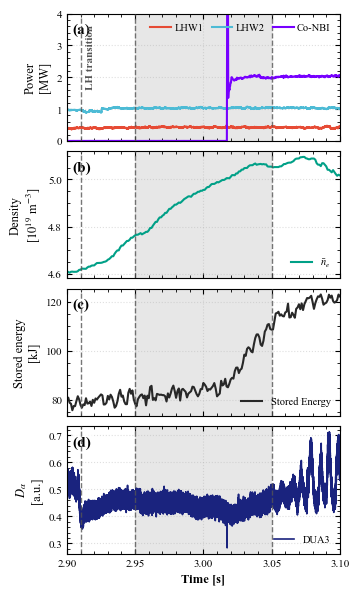

In [2]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
from spectrum_toolbox import MDSDataLoader

# ====================== 科研繪圖配置 (雙欄排版之單欄最佳化版) ======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],  
    'mathtext.fontset': 'stix',                  
    'axes.unicode_minus': False,                 
    'font.size': 9,                             # 基礎字號下調至 9pt，適合 3.5 吋寬度
    'axes.labelsize': 9,                        # 座標軸標籤字號
    'xtick.labelsize': 8,                       # 刻度字號下調至 8pt
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                     # 圖例字號調小，避免遮擋資料
    'xtick.direction': 'in',                    # 刻度朝內
    'ytick.direction': 'in',
    'xtick.top': True,                           
    'ytick.right': True,                         
    'axes.linewidth': 0.8                       # 外框線寬度稍微調細，避免在小圖中顯得笨重
})

# ====================== 參數設定 ======================
shot_num = 80491
t_start = 2.9
t_end   = 3.1

loader = MDSDataLoader()

# ====================== 資料讀取 ======================
# 1. 加熱功率 (LHW)
time_lhw, plhi1 = loader.get_signal(shot_num, '\\plhi1', (t_start, t_end), tree='east')
_, plhr1        = loader.get_signal(shot_num, '\\plhr1', (t_start, t_end), tree='east')
LHW1_total = (plhi1 - plhr1) / 1000.0

time_lhw, plhi2 = loader.get_signal(shot_num, '\\plhi2', (t_start, t_end), tree='east')
_, plhr2        = loader.get_signal(shot_num, '\\plhr2', (t_start, t_end), tree='east')
LHW2_total = (plhi2 - plhr2) / 1000.0

# 1. 加熱功率 (NBI)
time_nbi, pnbi1l = loader.get_signal(shot_num, '\\PNBI1LSOURCE', (t_start, t_end), tree='nbi_east')
_, pnbi1r        = loader.get_signal(shot_num, '\\PNBI1RSOURCE', (t_start, t_end), tree='nbi_east')
Co_NBI_total = (pnbi1l + pnbi1r) / 1000.0

time_nbi, pnbi2l = loader.get_signal(shot_num, '\\PNBI2LSOURCE', (t_start, t_end), tree='nbi_east')
_, pnbi2r        = loader.get_signal(shot_num, '\\PNBI2RSOURCE', (t_start, t_end), tree='nbi_east')
Ctr_NBI_total = (pnbi2l + pnbi2r) / 1000.0

# 2. 線平均密度 (ne_avg)
time_ne, ne_avg = loader.get_signal(shot_num, '\\dfsdev', (t_start, t_end), tree='pcs_east')

# 3. WMHD
time_wmhd, wmhd = loader.get_signal(shot_num, '\\eng', (t_start, t_end), tree='energy_east')

# 4. DUA3
time_dua, dua3  = loader.get_signal(shot_num, '\\dau3', (t_start, t_end), tree='east')

# ====================== 繪圖：4行1列，共用x軸 ======================
# 關鍵修改：寬度嚴格設定為 3.5 英寸 (單欄標準寬度)，高度 6 英寸
fig, axs = plt.subplots(4, 1, figsize=(3.5, 6), sharex=True)
# 使用 subplots_adjust 精確控制邊距與間距，充分利用有限的空間
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子圖編號樣式：字號配合整體比例縮小
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# ---------- 子圖 (a)：加熱功率 ----------
ax1 = axs[0]
ax1.plot(time_lhw, LHW1_total, color='#E64B35', linewidth=1.5, label='LHW1')       
ax1.plot(time_lhw, LHW2_total, color='#4DBBD5', linewidth=1.5, label='LHW2')       
ax1.plot(time_nbi, Co_NBI_total,  color="#7700FF", linewidth=1.5, label='Co-NBI')  

ax1.set_ylabel('Power\n[MW]') 
ax1.set_ylim(0, 4)
# 取消圖例邊框，設定單排並縮小列間距
ax1.legend(loc='upper right', ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.3)
ax1.grid(True, linestyle=':', alpha=0.4)
ax1.text(0.02, 0.92, '(a)', transform=ax1.transAxes, **letter_style)
ax1.minorticks_on()

# ---------- 子圖 (b)：線平均密度 ----------
ax2 = axs[1]
ax2.plot(time_ne, ne_avg, color="#00A087", linewidth=1.5, label=r'$\bar{n}_e$')  
ax2.set_ylabel('Density\n[$10^{19}$ m$^{-3}$]') 
ax2.legend(loc='lower right', frameon=False)
ax2.grid(True, linestyle=':', alpha=0.4)          
ax2.text(0.02, 0.92, '(b)', transform=ax2.transAxes, **letter_style)
ax2.minorticks_on()

# ---------- 子圖 (c)：WMHD ----------
ax3 = axs[2]
ax3.plot(time_wmhd, wmhd/1000.0, color="#282828", linewidth=1.5, label='Stored Energy')  
ax3.set_ylabel('Stored energy\n[kJ]')
ax3.legend(loc='lower right', frameon=False)
ax3.grid(True, linestyle=':', alpha=0.4)          
ax3.text(0.02, 0.92, '(c)', transform=ax3.transAxes, **letter_style)
ax3.minorticks_on()

# ---------- 子圖 (d)：DUA3 ----------
ax4 = axs[3]
# 波動劇烈的 DUA3 訊號線使用 1.2 的線寬，避免在小圖中顯得過於凌亂
ax4.plot(time_dua, dua3, color="#1A237E", linewidth=1.2, label='DUA3')          
ax4.set_ylabel('$D_{\\alpha}$\n[a.u.]')
ax4.set_xlabel('Time [s]', fontweight='bold')
ax4.legend(loc='lower right', frameon=False)
ax4.grid(True, linestyle=':', alpha=0.4)
ax4.text(0.02, 0.92, '(d)', transform=ax4.transAxes, **letter_style)
ax4.minorticks_on()

# ====================== 高亮陰影和虛線 ======================
highlight_start = 2.95
highlight_end = 3.05
LHtransition_time = 2.91

for ax in axs:
    ax.axvline(x=highlight_start, color='#555555', linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color='#555555', linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=LHtransition_time, color='#555555', linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)

ax.text(LHtransition_time+0.007, 0.4, 'LH transition', transform=axs[0].get_xaxis_transform(),
        fontsize=8, fontweight='bold', color='#555555', ha='center', va='bottom', rotation=90)

# 強制限制 X 軸顯示範圍，防止邊緣空白
ax4.set_xlim(t_start, t_end)

# ====================== 儲存與展示 ======================
save_name = f'Shot{shot_num}_{t_start}-{t_end}s_Overview_SingleColumn'

# 確保輸出目錄存在，如果沒有 D:\TEMP\論文圖v2，請先建立或修改路徑
import os
save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), bbox_inches='tight')

plt.show()

## 83961放电参数图

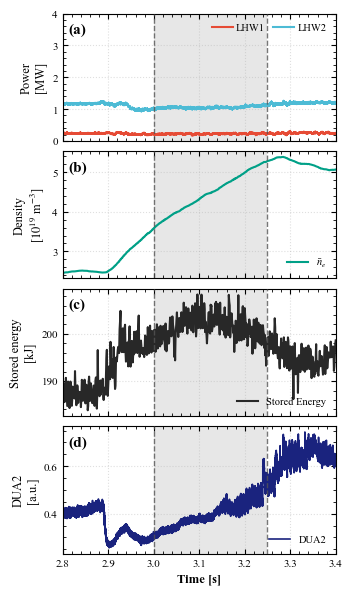

In [5]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
from spectrum_toolbox import MDSDataLoader

# ====================== 科研繪圖配置 (雙欄排版之單欄最佳化版) ======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],  
    'mathtext.fontset': 'stix',                  
    'axes.unicode_minus': False,                 
    'font.size': 9,                             # 基礎字號下調至 9pt，適合 3.5 吋寬度
    'axes.labelsize': 9,                        # 座標軸標籤字號
    'xtick.labelsize': 8,                       # 刻度字號下調至 8pt
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                     # 圖例字號調小，避免遮擋資料
    'xtick.direction': 'in',                    # 刻度朝內
    'ytick.direction': 'in',
    'xtick.top': True,                           
    'ytick.right': True,                         
    'axes.linewidth': 0.8                       # 外框線寬度稍微調細，避免在小圖中顯得笨重
})

# ====================== 參數設定 ======================
shot_num = 83961
t_start = 2.8
t_end   = 3.4

loader = MDSDataLoader()

# ====================== 資料讀取 ======================
# 1. 加熱功率 (LHW)
time_lhw, plhi1 = loader.get_signal(shot_num, '\\plhi1', (t_start, t_end), tree='east')
_, plhr1        = loader.get_signal(shot_num, '\\plhr1', (t_start, t_end), tree='east')
LHW1_total = (plhi1 - plhr1) / 1000.0

time_lhw, plhi2 = loader.get_signal(shot_num, '\\plhi2', (t_start, t_end), tree='east')
_, plhr2        = loader.get_signal(shot_num, '\\plhr2', (t_start, t_end), tree='east')
LHW2_total = (plhi2 - plhr2) / 1000.0

# 1. 加熱功率 (NBI)
time_nbi, pnbi1l = loader.get_signal(shot_num, '\\PNBI1LSOURCE', (t_start, t_end), tree='nbi_east')
_, pnbi1r        = loader.get_signal(shot_num, '\\PNBI1RSOURCE', (t_start, t_end), tree='nbi_east')
Co_NBI_total = (pnbi1l + pnbi1r) / 1000.0

time_nbi, pnbi2l = loader.get_signal(shot_num, '\\PNBI2LSOURCE', (t_start, t_end), tree='nbi_east')
_, pnbi2r        = loader.get_signal(shot_num, '\\PNBI2RSOURCE', (t_start, t_end), tree='nbi_east')
Ctr_NBI_total = (pnbi2l + pnbi2r) / 1000.0

# 2. 線平均密度 (ne_avg)
time_ne, ne_avg = loader.get_signal(shot_num, '\\dfsdev', (t_start, t_end), tree='pcs_east')

# 3. WMHD
time_wmhd, wmhd = loader.get_signal(shot_num, '\\eng', (t_start, t_end), tree='energy_east')

# 4. DUA2
time_dua, dua2  = loader.get_signal(shot_num, '\\dau2', (t_start, t_end), tree='east')

# ====================== 繪圖：4行1列，共用x軸 ======================
# 關鍵修改：寬度嚴格設定為 3.5 英寸 (單欄標準寬度)，高度 6 英寸
fig, axs = plt.subplots(4, 1, figsize=(3.5, 6), sharex=True)
# 使用 subplots_adjust 精確控制邊距與間距，充分利用有限的空間
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子圖編號樣式：字號配合整體比例縮小
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# ---------- 子圖 (a)：加熱功率 ----------
ax1 = axs[0]
ax1.plot(time_lhw, LHW1_total, color='#E64B35', linewidth=1.5, label='LHW1')       
ax1.plot(time_lhw, LHW2_total, color='#4DBBD5', linewidth=1.5, label='LHW2')       
# ax1.plot(time_nbi, Co_NBI_total,  color="#7700FF", linewidth=1.5, label='Co-NBI')  
# ax1.plot(time_nbi, Ctr_NBI_total, color="#FF69B4", linewidth=1.5, label='Ctr-NBI')  

ax1.set_ylabel('Power\n[MW]') 
ax1.set_ylim(0, 4)
# 取消圖例邊框，設定單排並縮小列間距
ax1.legend(loc='upper right', ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.3)
ax1.grid(True, linestyle=':', alpha=0.4)
ax1.text(0.02, 0.92, '(a)', transform=ax1.transAxes, **letter_style)
ax1.minorticks_on()

# ---------- 子圖 (b)：線平均密度 ----------
ax2 = axs[1]
ax2.plot(time_ne, ne_avg, color="#00A087", linewidth=1.5, label=r'$\bar{n}_e$')  
ax2.set_ylabel('Density\n[$10^{19}$ m$^{-3}$]') 
ax2.legend(loc='lower right', frameon=False)
ax2.grid(True, linestyle=':', alpha=0.4)          
ax2.text(0.02, 0.92, '(b)', transform=ax2.transAxes, **letter_style)
ax2.minorticks_on()

# ---------- 子圖 (c)：WMHD ----------
ax3 = axs[2]
ax3.plot(time_wmhd, wmhd/1000.0, color="#282828", linewidth=1.5, label='Stored Energy')  
ax3.set_ylabel('Stored energy\n[kJ]')
ax3.legend(loc='lower right', frameon=False)
ax3.grid(True, linestyle=':', alpha=0.4)          
ax3.text(0.02, 0.92, '(c)', transform=ax3.transAxes, **letter_style)
ax3.minorticks_on()

# ---------- 子圖 (d)：DUA2 ----------
ax4 = axs[3]
# 波動劇烈的 DUA2 訊號線使用 1.2 的線寬，避免在小圖中顯得過於凌亂
ax4.plot(time_dua, dua2, color="#1A237E", linewidth=1.2, label='DUA2')          
ax4.set_ylabel('DUA2\n[a.u.]')
ax4.set_xlabel('Time [s]', fontweight='bold')
ax4.legend(loc='lower right', frameon=False)
ax4.grid(True, linestyle=':', alpha=0.4)
ax4.text(0.02, 0.92, '(d)', transform=ax4.transAxes, **letter_style)
ax4.minorticks_on()

# ====================== 高亮陰影和虛線 ======================
highlight_start = 3.00
highlight_end = 3.25

for ax in axs:
    ax.axvline(x=highlight_start, color='#555555', linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color='#555555', linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)

# 強制限制 X 軸顯示範圍，防止邊緣空白
ax4.set_xlim(t_start, t_end)

# ====================== 儲存與展示 ======================
save_name = f'Shot{shot_num}_{t_start}-{t_end}s_Overview_SingleColumn'

# 確保輸出目錄存在，如果沒有 D:\TEMP\論文圖v2，請先建立或修改路徑
import os
save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), bbox_inches='tight')

plt.show()

## END

# 频谱图

## 80485

开始提取 Shot #80485 原始高分辨信号 (Judge=1)...
Processing Shot 80485 | Judge=1 | 5105A
  > Chunk 1/1 done.
开始提取 Shot #80485 幅度低频涨落信号 (Judge=2)...
Processing Shot 80485 | Judge=2 | 5105A
  > Chunk 1/1 done.


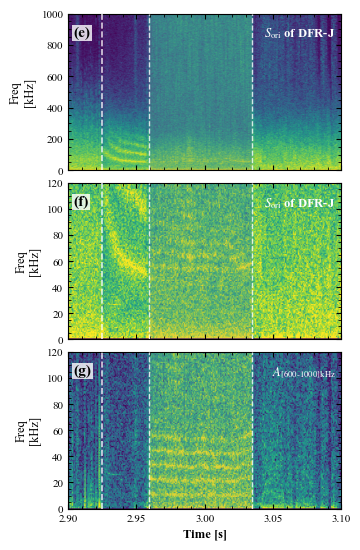

In [4]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

# 导入你编写的核心处理库
from NeFluc import ReflAnalyzer

# ====================== 科研绘图全局配置（双栏排版之单栏优化版）======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'], 
    'mathtext.fontset': 'stix',                  
    'axes.unicode_minus': False,                 
    'font.size': 9,                             # 基础字号下调至 9pt，适应 3.5 英寸宽度
    'axes.labelsize': 9,                        # 坐标轴标签字号
    'xtick.labelsize': 8,                       # 刻度字号下调至 8pt
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                     # 图例字号调小
    'xtick.direction': 'in',                    # 刻度向内
    'ytick.direction': 'in',                     
    'xtick.top': True,                           
    'ytick.right': True,                         
    'axes.linewidth': 0.8                       # 外框线宽度稍微调细，避免在小图中显得笨重
})

# ====================== 参数设置 ======================
shot_num = 80485
t_start = 2.9
t_end   = 3.1
channel_idx = 3  # 40 GHz 通道在 psds 列表中的索引为 3

# ====================== 数据提取计算 ======================
print(f"开始提取 Shot #{shot_num} 原始高分辨信号 (Judge=1)...")
analyzer_j1 = ReflAnalyzer(shot_num, t_start, t_end, judge=1)
t1, f1, psds1, freqs1 = analyzer_j1.run()

if t1 is None:
    raise ValueError("Judge=1 数据提取失败，请检查路径。")
psd_density_j1 = psds1[channel_idx]

print(f"开始提取 Shot #{shot_num} 幅度低频涨落信号 (Judge=2)...")
analyzer_j2 = ReflAnalyzer(shot_num, t_start, t_end, judge=2)
t2, f2, psds2, freqs2 = analyzer_j2.run()

if t2 is None:
    raise ValueError("Judge=2 数据提取失败，请检查路径。")
psd_density_j2 = psds2[channel_idx]

# ====================== 绘图：3行1列，共用x轴 ======================
# 宽度严格设置为 3.5 英寸 (单栏标准宽度)，高度 5.5 英寸
fig, axs = plt.subplots(3, 1, figsize=(3.5, 5.5), sharex=True)

# 移除标题后，将 top 边距调回 0.98，充分利用顶部空间
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子图编号样式：字号配合整体比例缩小至 11pt，减小 pad
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# ---------- 子图 (a)：Judge=1 (原始信号)，频率范围 0-1000 kHz ----------
ax1 = axs[0]
ReflAnalyzer.plot_on_axis(ax1, t1, f1, psd_density_j1)
# 覆盖 NeFluc 默认的 ylim 限制，展示宽频全貌
ax1.set_ylim(0, 1000)
ax1.set_ylabel('Freq\n[kHz]') # 换行缩短标签，节省左侧空间
ax1.minorticks_on()
ax1.text(0.02, 0.92, '(e)', transform=ax1.transAxes, **letter_style)
# 标注文字大小调至 9pt
ax1.text(0.98, 0.92, r'$S_{\text{ori}}$ of DFR-J', transform=ax1.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ---------- 子图 (b)：Judge=1 (原始信号)，频率范围 0-120 kHz ----------
ax2 = axs[1]
ReflAnalyzer.plot_on_axis(ax2, t1, f1, psd_density_j1)
# 保持默认的 0-120 kHz，用于观察低频精细结构
ax2.set_ylim(0, 120)
ax2.set_ylabel('Freq\n[kHz]')
ax2.minorticks_on()
ax2.text(0.02, 0.92, '(f)', transform=ax2.transAxes, **letter_style)
ax2.text(0.98, 0.92, r'$S_{\text{ori}}$ of DFR-J', transform=ax2.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ---------- 子图 (c)：Judge=2 (幅度信号)，频率范围 0-120 kHz ----------
ax3 = axs[2]
ReflAnalyzer.plot_on_axis(ax3, t2, f2, psd_density_j2)
ax3.set_ylim(0, 120)
ax3.set_ylabel('Freq\n[kHz]')
ax3.set_xlabel('Time [s]', fontweight='bold')
ax3.minorticks_on()
ax3.text(0.02, 0.92, '(g)', transform=ax3.transAxes, **letter_style)
ax3.text(0.98, 0.92, r'$A_{\text{[600-1000]kHz}}$', transform=ax3.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ====================== 重点修改区：添加高亮阴影和虚线 ======================
highlight_start = 2.959
highlight_end = 3.035
LHtransition_time = 2.925  # 可选：如果想在高亮区域内标记LH转变时间点

# 遍历三个子图，添加统一的高亮区域
for ax in axs:
    # 画两条纵向边界虚线（线条调细为 1.0）
    ax.axvline(x=highlight_start, color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    # 标记LH转变时间点（线宽调为 1.2）
    ax.axvline(x=LHtransition_time, color="#FFFFFF", linestyle='--', linewidth=1.2, alpha=0.8, zorder=3)  
    # 填充阴影区域
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)

# ---------- 保存与展示 ----------
# 强制设定 x 轴显示范围，防止边缘留白
ax3.set_xlim(t_start, t_end)

save_name = f'Shot{shot_num}_{t_start}-{t_end}s_40GHz_Spectrogram_Comparison_SingleColumn'

import os
save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

plt.show()

开始提取 Shot #80485 Doppler 原始高分辨信号 (Judge=1)...
Processing Shot 80485 | Judge=1 | Doppler
  > Chunk 1/1 done.
开始提取 Shot #80485 原始高分辨信号 (Judge=1)...
Processing Shot 80485 | Judge=1 | 5105A
  > Chunk 1/1 done.
开始提取 Shot #80485 幅度低频涨落信号 (Judge=2)...
Processing Shot 80485 | Judge=2 | 5105A
  > Chunk 1/1 done.


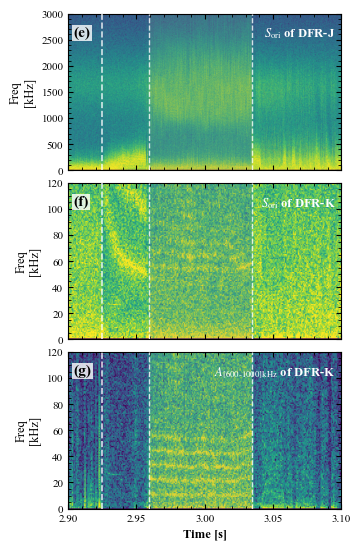

In [3]:
# -*- coding: utf-8 -*-
import os
import matplotlib.pyplot as plt
import numpy as np

# 导入你编写的核心处理库
from NeFluc import ReflAnalyzer

# ====================== 科研绘图全局配置（双栏排版之单栏优化版）======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 0.8
})

# ====================== 参数设置 ======================
shot_num = 80485
t_start = 2.9
t_end   = 3.1

# 5105A / DFR-J 的通道索引（你原来 40 GHz 对应 index=3）
channel_idx_j = 3

# Doppler 的通道索引
# Doppler 在你这份库里 freqs = [56, 61, 66, 70]
# 如果想画 70 GHz 对应通道，就保持 3
channel_idx_doppler = 3

# ====================== 数据提取计算 ======================

# ---------- 1) Doppler, Judge=1 ----------
print(f"开始提取 Shot #{shot_num} Doppler 原始高分辨信号 (Judge=1)...")
analyzer_dop = ReflAnalyzer(shot_num, t_start, t_end, judge=1)

# 强制切换到 Doppler
analyzer_dop.card_name = "Doppler"
analyzer_dop.fs = 20 * 10**6   # 20 MHz，确保读取和频率轴都按 Doppler 处理

t_dop, f_dop, psds_dop, freqs_dop = analyzer_dop.run()

if t_dop is None:
    raise ValueError("Doppler Judge=1 数据提取失败，请检查路径或 Doppler.bin 文件。")
psd_density_dop = psds_dop[channel_idx_doppler]

# ---------- 2) 原 DFR-J, Judge=1 ----------
print(f"开始提取 Shot #{shot_num} 原始高分辨信号 (Judge=1)...")
analyzer_j1 = ReflAnalyzer(shot_num, t_start, t_end, judge=1)
t1, f1, psds1, freqs1 = analyzer_j1.run()

if t1 is None:
    raise ValueError("Judge=1 数据提取失败，请检查路径。")
psd_density_j1 = psds1[channel_idx_j]

# ---------- 3) 原 DFR-J, Judge=2 ----------
print(f"开始提取 Shot #{shot_num} 幅度低频涨落信号 (Judge=2)...")
analyzer_j2 = ReflAnalyzer(shot_num, t_start, t_end, judge=2)
t2, f2, psds2, freqs2 = analyzer_j2.run()

if t2 is None:
    raise ValueError("Judge=2 数据提取失败，请检查路径。")
psd_density_j2 = psds2[channel_idx_j]

# ====================== 绘图：3行1列，共用x轴 ======================
fig, axs = plt.subplots(3, 1, figsize=(3.5, 5.5), sharex=True)
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子图编号样式
letter_style = dict(
    fontsize=11, fontweight='bold', va='top', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
)

# ---------- 子图 (a)：Doppler Judge=1，频率范围 0-3000 kHz ----------
ax1 = axs[0]
ReflAnalyzer.plot_on_axis(ax1, t_dop, f_dop, psd_density_dop)
ax1.set_ylim(0, 3000)
ax1.set_ylabel('Freq\n[kHz]')
ax1.minorticks_on()
ax1.text(0.02, 0.92, '(e)', transform=ax1.transAxes, **letter_style)
ax1.text(
    0.98, 0.92,
    rf'$S_{{\text{{ori}}}}$ of DFR-J',
    transform=ax1.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ---------- 子图 (b)：Judge=1 (原始信号)，频率范围 0-120 kHz ----------
ax2 = axs[1]
ReflAnalyzer.plot_on_axis(ax2, t1, f1, psd_density_j1)
ax2.set_ylim(0, 120)
ax2.set_ylabel('Freq\n[kHz]')
ax2.minorticks_on()
ax2.text(0.02, 0.92, '(f)', transform=ax2.transAxes, **letter_style)
ax2.text(
    0.98, 0.92,
    r'$S_{\text{ori}}$ of DFR-K',
    transform=ax2.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ---------- 子图 (c)：Judge=2 (幅度信号)，频率范围 0-120 kHz ----------
ax3 = axs[2]
ReflAnalyzer.plot_on_axis(ax3, t2, f2, psd_density_j2)
ax3.set_ylim(0, 120)
ax3.set_ylabel('Freq\n[kHz]')
ax3.set_xlabel('Time [s]', fontweight='bold')
ax3.minorticks_on()
ax3.text(0.02, 0.92, '(g)', transform=ax3.transAxes, **letter_style)
ax3.text(
    0.98, 0.92,
    r'$A_{\text{[600-1000]kHz}}$ of DFR-K',
    transform=ax3.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ====================== 添加高亮阴影和虚线 ======================
highlight_start = 2.959
highlight_end = 3.035
LHtransition_time = 2.925

for ax in axs:
    ax.axvline(x=highlight_start, color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=LHtransition_time, color="#FFFFFF", linestyle='--', linewidth=1.2, alpha=0.8, zorder=3)
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)

# ====================== 统一 x 轴范围 ======================
for ax in axs:
    ax.set_xlim(t_start, t_end)

# ---------- 保存与展示 ----------
save_name = f'Shot{shot_num}_{t_start}-{t_end}s_Doppler_DFRJ_Spectrogram_Comparison_SingleColumn'

save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

plt.show()

开始提取 Shot #80485 Doppler 原始高分辨信号 (Judge=1)...
Processing Shot 80485 | Judge=1 | Doppler
  > Chunk 1/1 done.
开始提取 Shot #80485 Doppler 幅度低频涨落信号 (Judge=2)...
Processing Shot 80485 | Judge=2 | Doppler
  > Chunk 1/1 done.
开始提取 Shot #80485 原始高分辨信号 (Judge=1)...
Processing Shot 80485 | Judge=1 | 5105A
  > Chunk 1/1 done.
开始提取 Shot #80485 幅度低频涨落信号 (Judge=2)...
Processing Shot 80485 | Judge=2 | 5105A
  > Chunk 1/1 done.


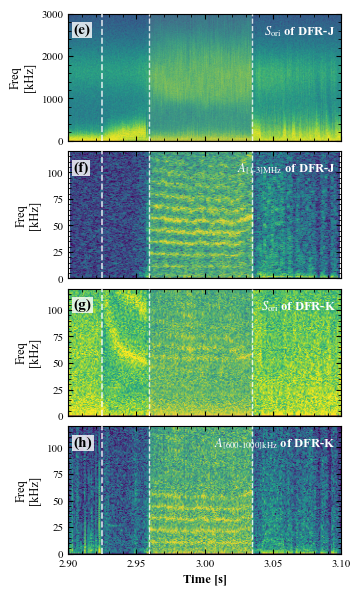

In [7]:
# -*- coding: utf-8 -*-
import os
import matplotlib.pyplot as plt
import numpy as np

# 导入你编写的核心处理库
from NeFluc import ReflAnalyzer

# ====================== 科研绘图全局配置（双栏排版之单栏优化版）======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 0.8
})

# ====================== 参数设置 ======================
shot_num = 80485
t_start = 2.9
t_end   = 3.1

# DFR-K 的通道索引（你原来 40 GHz 对应 index=3）
channel_idx_j = 3

# Doppler 的通道索引
# Doppler freqs = [56, 61, 66, 70]
channel_idx_doppler = 3   # 70 GHz

# ====================== 数据提取计算 ======================

# ---------- 1) Doppler, Judge=1 ----------
print(f"开始提取 Shot #{shot_num} Doppler 原始高分辨信号 (Judge=1)...")
analyzer_dop_j1 = ReflAnalyzer(shot_num, t_start, t_end, judge=1)
analyzer_dop_j1.card_name = "Doppler"
analyzer_dop_j1.fs = 20 * 10**6

# 只计算目标通道，降低内存占用
if hasattr(analyzer_dop_j1, 'target_channels'):
    analyzer_dop_j1.target_channels = [channel_idx_doppler]
if hasattr(analyzer_dop_j1, 'step_factor_j1_doppler'):
    analyzer_dop_j1.step_factor_j1_doppler = 2

t_dop1, f_dop1, psds_dop1, freqs_dop = analyzer_dop_j1.run()

if t_dop1 is None:
    raise ValueError("Doppler Judge=1 数据提取失败，请检查路径或 Doppler.bin 文件。")
psd_density_dop1 = psds_dop1[channel_idx_doppler]

# ---------- 2) Doppler, Judge=2 ----------
print(f"开始提取 Shot #{shot_num} Doppler 幅度低频涨落信号 (Judge=2)...")
analyzer_dop_j2 = ReflAnalyzer(shot_num, t_start, t_end, judge=2)
analyzer_dop_j2.card_name = "Doppler"
analyzer_dop_j2.fs = 20 * 10**6
analyzer_dop_j2.band_pass = [-3000, -1000]
analyzer_dop_j2.fftpoint_j2 = 1024
analyzer_dop_j2.step_factor_j2 = 4
analyzer_dop_j2.average_point = 40

if hasattr(analyzer_dop_j2, 'target_channels'):
    analyzer_dop_j2.target_channels = [channel_idx_doppler]

t_dop2, f_dop2, psds_dop2, _ = analyzer_dop_j2.run()

if t_dop2 is None:
    raise ValueError("Doppler Judge=2 数据提取失败，请检查路径或 Doppler.bin 文件。")
psd_density_dop2 = psds_dop2[channel_idx_doppler]

# ---------- 3) DFR-K, Judge=1 ----------
print(f"开始提取 Shot #{shot_num} 原始高分辨信号 (Judge=1)...")
analyzer_j1 = ReflAnalyzer(shot_num, t_start, t_end, judge=1)
t1, f1, psds1, freqs1 = analyzer_j1.run()

if t1 is None:
    raise ValueError("Judge=1 数据提取失败，请检查路径。")
psd_density_j1 = psds1[channel_idx_j]

# ---------- 4) DFR-K, Judge=2 ----------
print(f"开始提取 Shot #{shot_num} 幅度低频涨落信号 (Judge=2)...")
analyzer_j2 = ReflAnalyzer(shot_num, t_start, t_end, judge=2)
t2, f2, psds2, freqs2 = analyzer_j2.run()

if t2 is None:
    raise ValueError("Judge=2 数据提取失败，请检查路径。")
psd_density_j2 = psds2[channel_idx_j]

# ====================== 绘图：4行1列，共用x轴 ======================
fig, axs = plt.subplots(4, 1, figsize=(3.5, 6.0), sharex=True)
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子图编号样式
letter_style = dict(
    fontsize=11, fontweight='bold', va='top', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
)

# ---------- 子图 (e)：Doppler Judge=1，频率范围 0-3000 kHz ----------
ax1 = axs[0]
ReflAnalyzer.plot_on_axis(ax1, t_dop1, f_dop1, psd_density_dop1)
ax1.set_ylim(0, 3000)
ax1.set_ylabel('Freq\n[kHz]')
ax1.minorticks_on()
ax1.text(0.02, 0.92, '(e)', transform=ax1.transAxes, **letter_style)
ax1.text(
    0.98, 0.92,
    r'$S_{\text{ori}}$ of DFR-J',
    transform=ax1.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ---------- 子图 (f)：Doppler Judge=2，频率范围 0-120 kHz ----------
ax2 = axs[1]
ReflAnalyzer.plot_on_axis(ax2, t_dop2, f_dop2, psd_density_dop2)
ax2.set_ylim(0, 120)
ax2.set_ylabel('Freq\n[kHz]')
ax2.minorticks_on()
ax2.text(0.02, 0.92, '(f)', transform=ax2.transAxes, **letter_style)
ax2.text(
    0.98, 0.92,
    r'$A_{\text{[1-3]MHz}}$ of DFR-J',
    transform=ax2.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ---------- 子图 (g)：DFR-K Judge=1，频率范围 0-120 kHz ----------
ax3 = axs[2]
ReflAnalyzer.plot_on_axis(ax3, t1, f1, psd_density_j1)
ax3.set_ylim(0, 120)
ax3.set_ylabel('Freq\n[kHz]')
ax3.minorticks_on()
ax3.text(0.02, 0.92, '(g)', transform=ax3.transAxes, **letter_style)
ax3.text(
    0.98, 0.92,
    r'$S_{\text{ori}}$ of DFR-K',
    transform=ax3.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ---------- 子图 (h)：DFR-K Judge=2，频率范围 0-120 kHz ----------
ax4 = axs[3]
ReflAnalyzer.plot_on_axis(ax4, t2, f2, psd_density_j2)
ax4.set_ylim(0, 120)
ax4.set_ylabel('Freq\n[kHz]')
ax4.set_xlabel('Time [s]', fontweight='bold')
ax4.minorticks_on()
ax4.text(0.02, 0.92, '(h)', transform=ax4.transAxes, **letter_style)
ax4.text(
    0.98, 0.92,
    r'$A_{\text{[600-1000]kHz}}$ of DFR-K',
    transform=ax4.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ====================== 添加高亮阴影和虚线 ======================
highlight_start = 2.959
highlight_end = 3.035
LHtransition_time = 2.925

for ax in axs:
    ax.axvline(x=highlight_start, color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=LHtransition_time, color="#FFFFFF", linestyle='--', linewidth=1.2, alpha=0.8, zorder=3)
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)

# ====================== 统一 x 轴范围 ======================
for ax in axs:
    ax.set_xlim(t_start, t_end)

# ---------- 保存与展示 ----------
save_name = f'Shot{shot_num}_{t_start}-{t_end}s_Doppler_DFRK_Spectrogram_Comparison_4Panels'

save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

plt.show()

## 80491

开始提取 Shot #80491 原始高分辨信号 (Judge=1)...
Processing Shot 80491 | Judge=1 | 5105A
  > Chunk 1/1 done.
开始提取 Shot #80491 幅度低频涨落信号 (Judge=2)...
Processing Shot 80491 | Judge=2 | 5105A
  > Chunk 1/1 done.


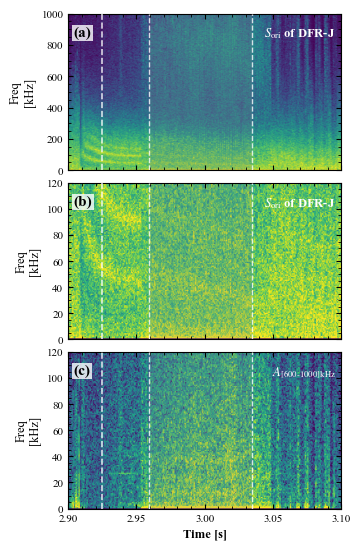

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

# 导入你编写的核心处理库
from NeFluc import ReflAnalyzer

# ====================== 科研绘图全局配置（双栏排版之单栏优化版）======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'], 
    'mathtext.fontset': 'stix',                  
    'axes.unicode_minus': False,                 
    'font.size': 9,                             # 基础字号下调至 9pt，适应 3.5 英寸宽度
    'axes.labelsize': 9,                        # 坐标轴标签字号
    'xtick.labelsize': 8,                       # 刻度字号下调至 8pt
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                     # 图例字号调小
    'xtick.direction': 'in',                    # 刻度向内
    'ytick.direction': 'in',                     
    'xtick.top': True,                           
    'ytick.right': True,                         
    'axes.linewidth': 0.8                       # 外框线宽度稍微调细，避免在小图中显得笨重
})

# ====================== 参数设置 ======================
shot_num = 80491
t_start = 2.9
t_end   = 3.1
channel_idx = 3  # 40 GHz 通道在 psds 列表中的索引为 3

# ====================== 数据提取计算 ======================
print(f"开始提取 Shot #{shot_num} 原始高分辨信号 (Judge=1)...")
analyzer_j1 = ReflAnalyzer(shot_num, t_start, t_end, judge=1)
t1, f1, psds1, freqs1 = analyzer_j1.run()

if t1 is None:
    raise ValueError("Judge=1 数据提取失败，请检查路径。")
psd_density_j1 = psds1[channel_idx]

print(f"开始提取 Shot #{shot_num} 幅度低频涨落信号 (Judge=2)...")
analyzer_j2 = ReflAnalyzer(shot_num, t_start, t_end, judge=2)
t2, f2, psds2, freqs2 = analyzer_j2.run()

if t2 is None:
    raise ValueError("Judge=2 数据提取失败，请检查路径。")
psd_density_j2 = psds2[channel_idx]

# ====================== 绘图：3行1列，共用x轴 ======================
# 宽度严格设置为 3.5 英寸 (单栏标准宽度)，高度 5.5 英寸
fig, axs = plt.subplots(3, 1, figsize=(3.5, 5.5), sharex=True)

# 移除标题后，将 top 边距调回 0.98，充分利用顶部空间
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子图编号样式：字号配合整体比例缩小至 11pt，减小 pad
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# ---------- 子图 (a)：Judge=1 (原始信号)，频率范围 0-1000 kHz ----------
ax1 = axs[0]
ReflAnalyzer.plot_on_axis(ax1, t1, f1, psd_density_j1)
# 覆盖 NeFluc 默认的 ylim 限制，展示宽频全貌
ax1.set_ylim(0, 1000)
ax1.set_ylabel('Freq\n[kHz]') # 换行缩短标签，节省左侧空间
ax1.minorticks_on()
ax1.text(0.02, 0.92, '(e)', transform=ax1.transAxes, **letter_style)
# 标注文字大小调至 9pt
ax1.text(0.98, 0.92, r'$S_{\text{ori}}$ of DFR-J', transform=ax1.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ---------- 子图 (b)：Judge=1 (原始信号)，频率范围 0-120 kHz ----------
ax2 = axs[1]
ReflAnalyzer.plot_on_axis(ax2, t1, f1, psd_density_j1)
# 保持默认的 0-120 kHz，用于观察低频精细结构
ax2.set_ylim(0, 120)
ax2.set_ylabel('Freq\n[kHz]')
ax2.minorticks_on()
ax2.text(0.02, 0.92, '(f)', transform=ax2.transAxes, **letter_style)
ax2.text(0.98, 0.92, r'$S_{\text{ori}}$ of DFR-J', transform=ax2.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ---------- 子图 (c)：Judge=2 (幅度信号)，频率范围 0-120 kHz ----------
ax3 = axs[2]
ReflAnalyzer.plot_on_axis(ax3, t2, f2, psd_density_j2)
ax3.set_ylim(0, 120)
ax3.set_ylabel('Freq\n[kHz]')
ax3.set_xlabel('Time [s]', fontweight='bold')
ax3.minorticks_on()
ax3.text(0.02, 0.92, '(g)', transform=ax3.transAxes, **letter_style)
ax3.text(0.98, 0.92, r'$A_{\text{[600-1000]kHz}}$', transform=ax3.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ====================== 重点修改区：添加高亮阴影和虚线 ======================
highlight_start = 2.959
highlight_end = 3.035
LHtransition_time = 2.925  # 可选：如果想在高亮区域内标记LH转变时间点

# 遍历三个子图，添加统一的高亮区域
for ax in axs:
    # 画两条纵向边界虚线（线条调细为 1.0）
    ax.axvline(x=highlight_start, color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    # 标记LH转变时间点（线宽调为 1.2）
    ax.axvline(x=LHtransition_time, color="#FFFFFF", linestyle='--', linewidth=1.2, alpha=0.8, zorder=3)  
    # 填充阴影区域
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)

# ---------- 保存与展示 ----------
# 强制设定 x 轴显示范围，防止边缘留白
ax3.set_xlim(t_start, t_end)

save_name = f'Shot{shot_num}_{t_start}-{t_end}s_40GHz_Spectrogram_Comparison_SingleColumn'

import os
save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

plt.show()

开始提取 Shot #80491 Doppler 原始高分辨信号 (Judge=1)...
Processing Shot 80491 | Judge=1 | Doppler
  > Chunk 1/1 done.
开始提取 Shot #80491 Doppler 幅度低频涨落信号 (Judge=2)...
Processing Shot 80491 | Judge=2 | Doppler
  > Chunk 1/1 done.
开始提取 Shot #80491 原始高分辨信号 (Judge=1)...
Processing Shot 80491 | Judge=1 | 5105A
  > Chunk 1/1 done.
开始提取 Shot #80491 幅度低频涨落信号 (Judge=2)...
Processing Shot 80491 | Judge=2 | 5105A
  > Chunk 1/1 done.


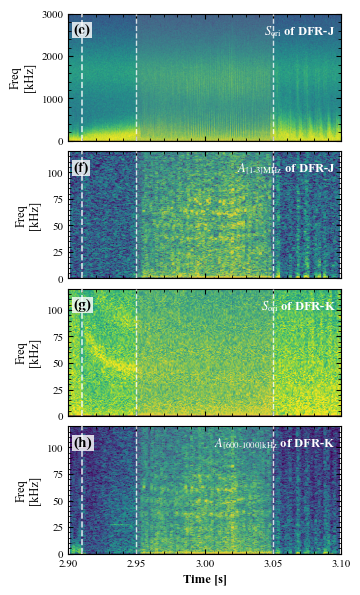

In [13]:
# -*- coding: utf-8 -*-
import os
import matplotlib.pyplot as plt
import numpy as np

# 导入你编写的核心处理库
from NeFluc import ReflAnalyzer

# ====================== 科研绘图全局配置（双栏排版之单栏优化版）======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 0.8
})

# ====================== 参数设置 ======================
shot_num = 80491
t_start = 2.9
t_end   = 3.1

# DFR-K 的通道索引（你原来 40 GHz 对应 index=3）
channel_idx_j = 2

# Doppler 的通道索引
# Doppler freqs = [56, 61, 66, 70]
channel_idx_doppler = 3   # 70 GHz

# ====================== 数据提取计算 ======================

# ---------- 1) Doppler, Judge=1 ----------
print(f"开始提取 Shot #{shot_num} Doppler 原始高分辨信号 (Judge=1)...")
analyzer_dop_j1 = ReflAnalyzer(shot_num, t_start, t_end, judge=1)
analyzer_dop_j1.card_name = "Doppler"
analyzer_dop_j1.fs = 20 * 10**6

# 只计算目标通道，降低内存占用
if hasattr(analyzer_dop_j1, 'target_channels'):
    analyzer_dop_j1.target_channels = [channel_idx_doppler]
if hasattr(analyzer_dop_j1, 'step_factor_j1_doppler'):
    analyzer_dop_j1.step_factor_j1_doppler = 2

t_dop1, f_dop1, psds_dop1, freqs_dop = analyzer_dop_j1.run()

if t_dop1 is None:
    raise ValueError("Doppler Judge=1 数据提取失败，请检查路径或 Doppler.bin 文件。")
psd_density_dop1 = psds_dop1[channel_idx_doppler]

# ---------- 2) Doppler, Judge=2 ----------
print(f"开始提取 Shot #{shot_num} Doppler 幅度低频涨落信号 (Judge=2)...")
analyzer_dop_j2 = ReflAnalyzer(shot_num, t_start, t_end, judge=2)
analyzer_dop_j2.card_name = "Doppler"
analyzer_dop_j2.fs = 20 * 10**6
analyzer_dop_j2.band_pass = [-3000, -1000]
analyzer_dop_j2.fftpoint_j2 = 1024
analyzer_dop_j2.step_factor_j2 = 4
analyzer_dop_j2.average_point = 40

if hasattr(analyzer_dop_j2, 'target_channels'):
    analyzer_dop_j2.target_channels = [channel_idx_doppler]

t_dop2, f_dop2, psds_dop2, _ = analyzer_dop_j2.run()

if t_dop2 is None:
    raise ValueError("Doppler Judge=2 数据提取失败，请检查路径或 Doppler.bin 文件。")
psd_density_dop2 = psds_dop2[channel_idx_doppler]

# ---------- 3) DFR-K, Judge=1 ----------
print(f"开始提取 Shot #{shot_num} 原始高分辨信号 (Judge=1)...")
analyzer_j1 = ReflAnalyzer(shot_num, t_start, t_end, judge=1)
analyzer_j1.average_point = 8
t1, f1, psds1, freqs1 = analyzer_j1.run()

if t1 is None:
    raise ValueError("Judge=1 数据提取失败，请检查路径。")
psd_density_j1 = psds1[channel_idx_j]

# ---------- 4) DFR-K, Judge=2 ----------
print(f"开始提取 Shot #{shot_num} 幅度低频涨落信号 (Judge=2)...")
analyzer_j2 = ReflAnalyzer(shot_num, t_start, t_end, judge=2)
analyzer_j2.average_point = 8
t2, f2, psds2, freqs2 = analyzer_j2.run()

if t2 is None:
    raise ValueError("Judge=2 数据提取失败，请检查路径。")
psd_density_j2 = psds2[channel_idx_j]

# ====================== 绘图：4行1列，共用x轴 ======================
fig, axs = plt.subplots(4, 1, figsize=(3.5, 6.0), sharex=True)
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子图编号样式
letter_style = dict(
    fontsize=11, fontweight='bold', va='top', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
)

# ---------- 子图 (e)：Doppler Judge=1，频率范围 0-3000 kHz ----------
ax1 = axs[0]
ReflAnalyzer.plot_on_axis(ax1, t_dop1, f_dop1, psd_density_dop1)
ax1.set_ylim(0, 3000)
ax1.set_ylabel('Freq\n[kHz]')
ax1.minorticks_on()
ax1.text(0.02, 0.92, '(e)', transform=ax1.transAxes, **letter_style)
ax1.text(
    0.98, 0.92,
    r'$S_{\text{ori}}$ of DFR-J',
    transform=ax1.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ---------- 子图 (f)：Doppler Judge=2，频率范围 0-120 kHz ----------
ax2 = axs[1]
ReflAnalyzer.plot_on_axis(ax2, t_dop2, f_dop2, psd_density_dop2)
ax2.set_ylim(0, 120)
ax2.set_ylabel('Freq\n[kHz]')
ax2.minorticks_on()
ax2.text(0.02, 0.92, '(f)', transform=ax2.transAxes, **letter_style)
ax2.text(
    0.98, 0.92,
    r'$A_{\text{[1-3]MHz}}$ of DFR-J',
    transform=ax2.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ---------- 子图 (g)：DFR-K Judge=1，频率范围 0-120 kHz ----------
ax3 = axs[2]
ReflAnalyzer.plot_on_axis(ax3, t1, f1, psd_density_j1)
ax3.set_ylim(0, 120)
ax3.set_ylabel('Freq\n[kHz]')
ax3.minorticks_on()
ax3.text(0.02, 0.92, '(g)', transform=ax3.transAxes, **letter_style)
ax3.text(
    0.98, 0.92,
    r'$S_{\text{ori}}$ of DFR-K',
    transform=ax3.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ---------- 子图 (h)：DFR-K Judge=2，频率范围 0-120 kHz ----------
ax4 = axs[3]
ReflAnalyzer.plot_on_axis(ax4, t2, f2, psd_density_j2)
ax4.set_ylim(0, 120)
ax4.set_ylabel('Freq\n[kHz]')
ax4.set_xlabel('Time [s]', fontweight='bold')
ax4.minorticks_on()
ax4.text(0.02, 0.92, '(h)', transform=ax4.transAxes, **letter_style)
ax4.text(
    0.98, 0.92,
    r'$A_{\text{[600-1000]kHz}}$ of DFR-K',
    transform=ax4.transAxes,
    fontsize=9, fontweight='bold', color='white', ha='right', va='top'
)

# ====================== 添加高亮阴影和虚线 ======================
highlight_start = 2.95
highlight_end = 3.05
LHtransition_time = 2.91  # 可选：如果想在高亮区域内标记LH转变时间点

for ax in axs:
    ax.axvline(x=highlight_start, color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=LHtransition_time, color="#FFFFFF", linestyle='--', linewidth=1.2, alpha=0.8, zorder=3)
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)

# ====================== 统一 x 轴范围 ======================
for ax in axs:
    ax.set_xlim(t_start, t_end)

# ---------- 保存与展示 ----------
save_name = f'Shot{shot_num}_{t_start}-{t_end}s_Doppler_DFRK_Spectrogram_Comparison_4Panels'

save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

plt.show()

## 83961

开始提取 Shot #83961 原始高分辨信号 (Judge=1)...
Processing Shot 83961 | Judge=1 | O_P1
  > Chunk 1/2 done.
  > Chunk 2/2 done.
开始提取 Shot #83961 幅度低频涨落信号 (Judge=2)...
Processing Shot 83961 | Judge=2 | O_P1
  > Chunk 1/2 done.
  > Chunk 2/2 done.


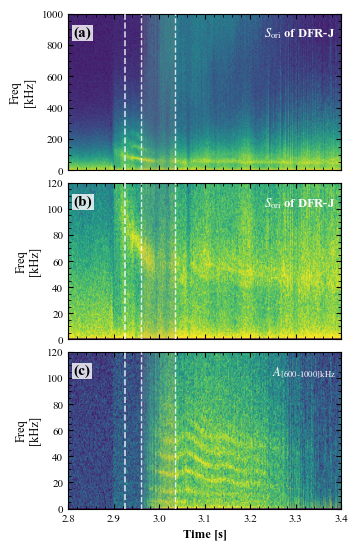

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

# 导入你编写的核心处理库
from NeFluc import ReflAnalyzer

# ====================== 科研绘图全局配置（双栏排版之单栏优化版）======================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'], 
    'mathtext.fontset': 'stix',                  
    'axes.unicode_minus': False,                 
    'font.size': 9,                             # 基础字号下调至 9pt，适应 3.5 英寸宽度
    'axes.labelsize': 9,                        # 坐标轴标签字号
    'xtick.labelsize': 8,                       # 刻度字号下调至 8pt
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                     # 图例字号调小
    'xtick.direction': 'in',                    # 刻度向内
    'ytick.direction': 'in',                     
    'xtick.top': True,                           
    'ytick.right': True,                         
    'axes.linewidth': 0.8                       # 外框线宽度稍微调细，避免在小图中显得笨重
})

# ====================== 参数设置 ======================
shot_num = 83961
t_start = 2.8
t_end   = 3.4
channel_idx = 3  # 40 GHz 通道在 psds 列表中的索引为 3

# ====================== 数据提取计算 ======================
print(f"开始提取 Shot #{shot_num} 原始高分辨信号 (Judge=1)...")
analyzer_j1 = ReflAnalyzer(shot_num, t_start, t_end, judge=1)
t1, f1, psds1, freqs1 = analyzer_j1.run()

if t1 is None:
    raise ValueError("Judge=1 数据提取失败，请检查路径。")
psd_density_j1 = psds1[channel_idx]

print(f"开始提取 Shot #{shot_num} 幅度低频涨落信号 (Judge=2)...")
analyzer_j2 = ReflAnalyzer(shot_num, t_start, t_end, judge=2)
t2, f2, psds2, freqs2 = analyzer_j2.run()

if t2 is None:
    raise ValueError("Judge=2 数据提取失败，请检查路径。")
psd_density_j2 = psds2[channel_idx]

# ====================== 绘图：3行1列，共用x轴 ======================
# 宽度严格设置为 3.5 英寸 (单栏标准宽度)，高度 5.5 英寸
fig, axs = plt.subplots(3, 1, figsize=(3.5, 5.5), sharex=True)

# 移除标题后，将 top 边距调回 0.98，充分利用顶部空间
fig.subplots_adjust(hspace=0.08, left=0.18, right=0.96, top=0.98, bottom=0.08)

# 子图编号样式：字号配合整体比例缩小至 11pt，减小 pad
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# ---------- 子图 (a)：Judge=1 (原始信号)，频率范围 0-1000 kHz ----------
ax1 = axs[0]
ReflAnalyzer.plot_on_axis(ax1, t1, f1, psd_density_j1)
# 覆盖 NeFluc 默认的 ylim 限制，展示宽频全貌
ax1.set_ylim(0, 1000)
ax1.set_ylabel('Freq\n[kHz]') # 换行缩短标签，节省左侧空间
ax1.minorticks_on()
ax1.text(0.02, 0.92, '(e)', transform=ax1.transAxes, **letter_style)
# 标注文字大小调至 9pt
ax1.text(0.98, 0.92, r'$S_{\text{ori}}$ of DFR-J', transform=ax1.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ---------- 子图 (b)：Judge=1 (原始信号)，频率范围 0-120 kHz ----------
ax2 = axs[1]
ReflAnalyzer.plot_on_axis(ax2, t1, f1, psd_density_j1)
# 保持默认的 0-120 kHz，用于观察低频精细结构
ax2.set_ylim(0, 120)
ax2.set_ylabel('Freq\n[kHz]')
ax2.minorticks_on()
ax2.text(0.02, 0.92, '(f)', transform=ax2.transAxes, **letter_style)
ax2.text(0.98, 0.92, r'$S_{\text{ori}}$ of DFR-J', transform=ax2.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ---------- 子图 (c)：Judge=2 (幅度信号)，频率范围 0-120 kHz ----------
ax3 = axs[2]
ReflAnalyzer.plot_on_axis(ax3, t2, f2, psd_density_j2)
ax3.set_ylim(0, 120)
ax3.set_ylabel('Freq\n[kHz]')
ax3.set_xlabel('Time [s]', fontweight='bold')
ax3.minorticks_on()
ax3.text(0.02, 0.92, '(g)', transform=ax3.transAxes, **letter_style)
ax3.text(0.98, 0.92, r'$A_{\text{[600-1000]kHz}}$', transform=ax3.transAxes, 
         fontsize=9, fontweight='bold', color='white', ha='right', va='top')

# ====================== 重点修改区：添加高亮阴影和虚线 ======================
highlight_start = 2.959
highlight_end = 3.035
LHtransition_time = 2.925  # 可选：如果想在高亮区域内标记LH转变时间点

# 遍历三个子图，添加统一的高亮区域
for ax in axs:
    # 画两条纵向边界虚线（线条调细为 1.0）
    ax.axvline(x=highlight_start, color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    ax.axvline(x=highlight_end,   color="#FFFFFF", linestyle='--', linewidth=1.0, alpha=0.8, zorder=3)
    # 标记LH转变时间点（线宽调为 1.2）
    ax.axvline(x=LHtransition_time, color="#FFFFFF", linestyle='--', linewidth=1.2, alpha=0.8, zorder=3)  
    # 填充阴影区域
    ax.axvspan(highlight_start, highlight_end, facecolor='#888888', alpha=0.2, zorder=1)

# ---------- 保存与展示 ----------
# 强制设定 x 轴显示范围，防止边缘留白
ax3.set_xlim(t_start, t_end)

save_name = f'Shot{shot_num}_{t_start}-{t_end}s_40GHz_Spectrogram_Comparison_SingleColumn'

import os
save_dir = r'D:\SHARE\论文图v2'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

plt.show()

## END

# 剖面数据

## 电子温度

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\p'
C:\Users\weiho\AppData\Local\Temp\ipykernel_32464\3964578636.py:30: SyntaxWarning: invalid escape sequence '\s'
  df_fit = pd.read_csv('80491te2.917fitted.txt', sep='\s+', header=None, names=['x_fit', 'y_fit'])
C:\Users\weiho\AppData\Local\Temp\ipykernel_32464\3964578636.py:58: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('$\psi$', fontsize=14, fontweight='bold')


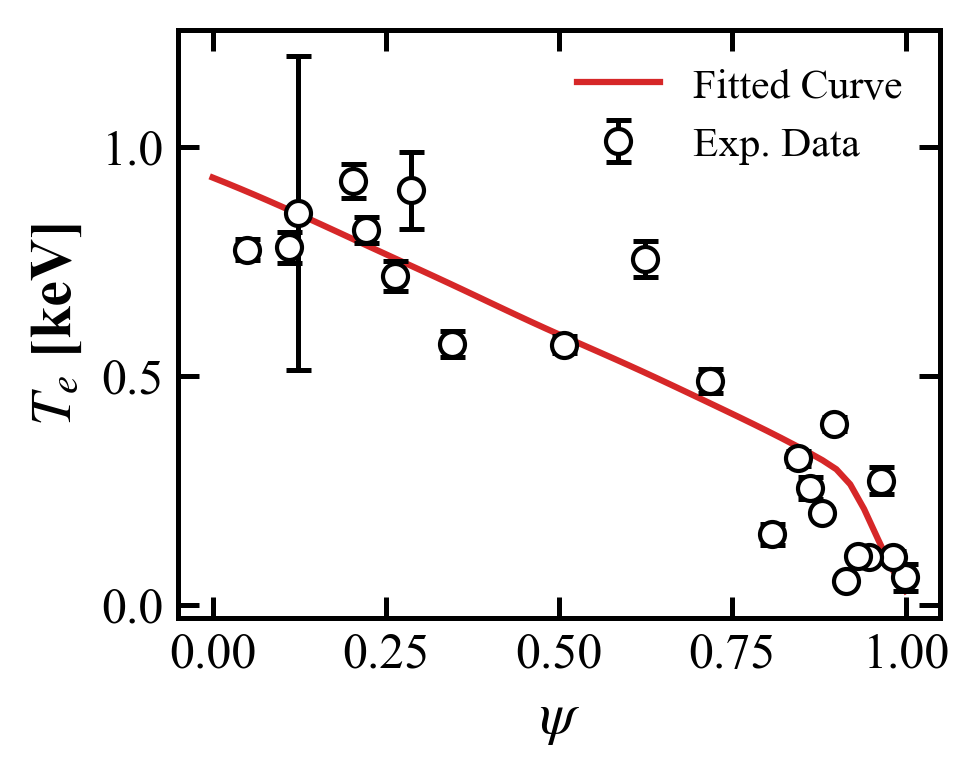

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 0. 全局科研绘图格式设置 (非常关键)
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'  # 科技论文标准字体
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学公式字体使其与 Times 匹配
plt.rcParams['font.size'] = 12                   # 基础字号
plt.rcParams['axes.linewidth'] = 1.2             # 坐标轴边框线宽
plt.rcParams['xtick.direction'] = 'in'           # X轴刻度向内 (标准要求)
plt.rcParams['ytick.direction'] = 'in'           # Y轴刻度向内 (标准要求)
plt.rcParams['xtick.top'] = True                 # 顶部显示刻度
plt.rcParams['ytick.right'] = True               # 右侧显示刻度
plt.rcParams['xtick.major.width'] = 1.2          # X轴主刻度线宽
plt.rcParams['ytick.major.width'] = 1.2          # Y轴主刻度线宽
plt.rcParams['xtick.major.size'] = 5             # X轴主刻度长度
plt.rcParams['ytick.major.size'] = 5             # Y轴主刻度长度

# ==========================================
# 1. 读取数据
# ==========================================
# 读取实验散点数据
df_exp = pd.read_csv('80491TeProfile2917.csv')
df_exp = df_exp.drop_duplicates().reset_index(drop=True)

# --- 新增：读取拟合曲线的 txt 数据 ---
# sep='\s+' 自动匹配任意数量的空格或制表符（Tab）
# header=None 表示文件没有表头，我们手动赋予列名 'x_fit' 和 'y_fit'
df_fit = pd.read_csv('80491te2.917fitted.txt', sep='\s+', header=None, names=['x_fit', 'y_fit'])

# --- 2. 设置平移量 ---
x_shift = -0.07

# 3. 应用平移 (仅平移实验数据，如果拟合数据也需要平移，可以在下面加一行)
x_final = df_exp['x_axis'] + x_shift
y = df_exp['y_value']
y_err = [df_exp['y_error_low'], df_exp['y_error_high']]

# ==========================================
# 4. 绘图
# ==========================================
fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

# 5. 绘制拟合曲线 (底层)
# color='#d62728' 是非常沉稳的深红色；zorder=1 确保曲线在点图层的下方
ax.plot(df_fit['x_fit'], df_fit['y_fit'], color='#d62728', linewidth=1.5, zorder=1, label='Fitted Curve')

# 6. 绘制科研标准的 Error Bar (顶层)
# zorder=2 确保散点图在最上方，不会被红线遮挡住点内部的白色
ax.errorbar(x_final, y, yerr=y_err, fmt='o', 
             markerfacecolor='white', markeredgecolor='black', 
             color='black', elinewidth=1.2, capsize=3, capthick=1.2, 
             markersize=6, zorder=2, label=f'Exp. Data')

# 7. 设置坐标轴标签
# 注意：变量倾斜，单位正体。所以 [keV] 放在了 $$ 外面
ax.set_xlabel('$\psi$', fontsize=14, fontweight='bold')
ax.set_ylabel('$T_e$ [keV]', fontsize=14, fontweight='bold')

# 8. 图例设置 
ax.legend(frameon=False, loc='best', fontsize=10)

# 取消网格线
ax.grid(False) 

# 紧凑布局
plt.tight_layout()
save_name = f'Shot_80491_TeProfile_Comparison_2917'

import os
save_dir = r'D:\MyPythonCodes\CGYRO_results\论文图片'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')
# 显示图像
plt.show()

## 3.017s

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:58: SyntaxWarning: invalid escape sequence '\p'
C:\Users\weiho\AppData\Local\Temp\ipykernel_32464\779628166.py:30: SyntaxWarning: invalid escape sequence '\s'
  df_fit = pd.read_csv('80491te3.017fitted.txt', sep='\s+', header=None, names=['x_fit', 'y_fit'])
C:\Users\weiho\AppData\Local\Temp\ipykernel_32464\779628166.py:58: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('$\psi$', fontsize=14, fontweight='bold')


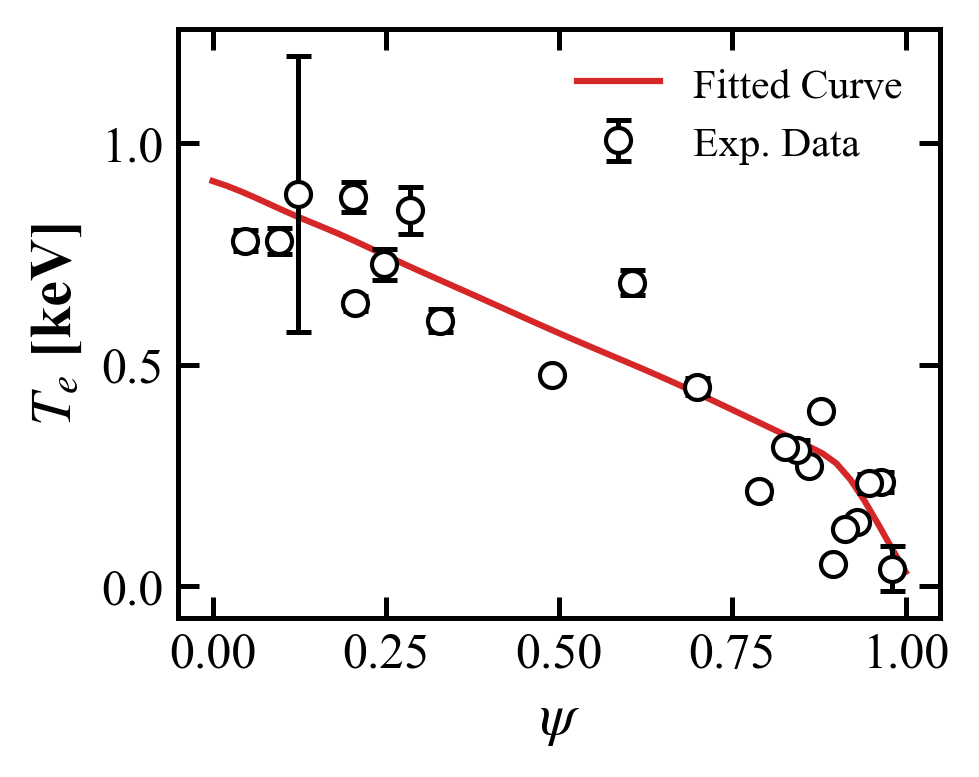

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 0. 全局科研绘图格式设置 (非常关键)
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'  # 科技论文标准字体
plt.rcParams['mathtext.fontset'] = 'stix'        # 数学公式字体使其与 Times 匹配
plt.rcParams['font.size'] = 12                   # 基础字号
plt.rcParams['axes.linewidth'] = 1.2             # 坐标轴边框线宽
plt.rcParams['xtick.direction'] = 'in'           # X轴刻度向内 (标准要求)
plt.rcParams['ytick.direction'] = 'in'           # Y轴刻度向内 (标准要求)
plt.rcParams['xtick.top'] = True                 # 顶部显示刻度
plt.rcParams['ytick.right'] = True               # 右侧显示刻度
plt.rcParams['xtick.major.width'] = 1.2          # X轴主刻度线宽
plt.rcParams['ytick.major.width'] = 1.2          # Y轴主刻度线宽
plt.rcParams['xtick.major.size'] = 5             # X轴主刻度长度
plt.rcParams['ytick.major.size'] = 5             # Y轴主刻度长度

# ==========================================
# 1. 读取数据
# ==========================================
# 读取实验散点数据
df_exp = pd.read_csv('80491TeProfile3017.csv')
df_exp = df_exp.drop_duplicates().reset_index(drop=True)

# --- 新增：读取拟合曲线的 txt 数据 ---
# sep='\s+' 自动匹配任意数量的空格或制表符（Tab）
# header=None 表示文件没有表头，我们手动赋予列名 'x_fit' 和 'y_fit'
df_fit = pd.read_csv('80491te3.017fitted.txt', sep='\s+', header=None, names=['x_fit', 'y_fit'])

# --- 2. 设置平移量 ---
x_shift = -0.07

# 3. 应用平移 (仅平移实验数据，如果拟合数据也需要平移，可以在下面加一行)
x_final = df_exp['x_axis'] + x_shift
y = df_exp['y_value']
y_err = [df_exp['y_error_low'], df_exp['y_error_high']]

# ==========================================
# 4. 绘图
# ==========================================
fig, ax = plt.subplots(figsize=(3.5, 2.8), dpi=300)

# 5. 绘制拟合曲线 (底层)
# color='#d62728' 是非常沉稳的深红色；zorder=1 确保曲线在点图层的下方
ax.plot(df_fit['x_fit'], df_fit['y_fit'], color='#d62728', linewidth=1.5, zorder=1, label='Fitted Curve')

# 6. 绘制科研标准的 Error Bar (顶层)
# zorder=2 确保散点图在最上方，不会被红线遮挡住点内部的白色
ax.errorbar(x_final, y, yerr=y_err, fmt='o', 
             markerfacecolor='white', markeredgecolor='black', 
             color='black', elinewidth=1.2, capsize=3, capthick=1.2, 
             markersize=6, zorder=2, label=f'Exp. Data')

# 7. 设置坐标轴标签
# 注意：变量倾斜，单位正体。所以 [keV] 放在了 $$ 外面
ax.set_xlabel('$\psi$', fontsize=14, fontweight='bold')
ax.set_ylabel('$T_e$ [keV]', fontsize=14, fontweight='bold')

# 8. 图例设置 
ax.legend(frameon=False, loc='best', fontsize=10)

# 取消网格线
ax.grid(False) 

# 紧凑布局
plt.tight_layout()
save_name = f'Shot_80491_TeProfile_Comparison_3017'

import os
save_dir = r'D:\MyPythonCodes\CGYRO_results\论文图片'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')
# 显示图像
plt.show()

## 合起来

图片已成功优化并保存至: D:\MyPythonCodes\CGYRO_results\论文图片


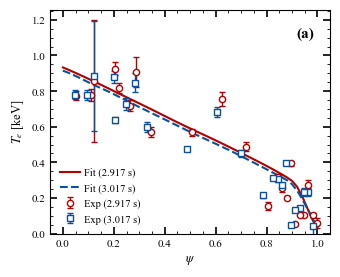

In [63]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 0. 科研绘图全局配置 (顶级期刊单栏规范: 3.5英寸宽)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'], # 优先使用 Times New Roman，兼容宋体
    'mathtext.fontset': 'stix',                  # 公式字体匹配
    'axes.unicode_minus': False,                 
    'font.size': 9,                              # 适合单栏 (3.5 英寸) 的基础字号
    'axes.labelsize': 9,                         
    'xtick.labelsize': 8,                        
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                      # 图例字号调小，避免遮挡数据
    'xtick.direction': 'in',                     # 刻度线向内
    'ytick.direction': 'in',
    'xtick.top': True,                           # 开启顶部和右侧刻度
    'ytick.right': True,                         
    'axes.linewidth': 0.8                        # 边框线宽稍微调细
})

# ==========================================
# 1. 读取并处理数据
# ==========================================
x_shift = -0.07  # 实验数据的统一平移量

# 封装安全读取，防止文件缺失报错
def safe_read(filepath, is_txt=False):
    try:
        if is_txt:
            return pd.read_csv(filepath, sep=r'\s+', header=None, names=['x_fit', 'y_fit'])
        else:
            return pd.read_csv(filepath).drop_duplicates().reset_index(drop=True)
    except FileNotFoundError:
        print(f"警告：找不到文件 {filepath}，请检查路径。")
        return pd.DataFrame()

# --- 读取 2917 组数据 ---
df_exp_2917 = safe_read('80491TeProfile2917.csv', is_txt=False)
df_fit_2917 = safe_read('80491te2.917fitted.txt', is_txt=True)

if not df_exp_2917.empty:
    x_final_2917 = df_exp_2917['x_axis'] + x_shift
    y_2917 = df_exp_2917['y_value']
    y_err_2917 = [df_exp_2917['y_error_low'], df_exp_2917['y_error_high']]

# --- 读取 3017 组数据 ---
df_exp_3017 = safe_read('80491TeProfile3017.csv', is_txt=False)
df_fit_3017 = safe_read('80491te3.017fitted.txt', is_txt=True)

if not df_exp_3017.empty:
    x_final_3017 = df_exp_3017['x_axis'] + x_shift
    y_3017 = df_exp_3017['y_value']
    y_err_3017 = [df_exp_3017['y_error_low'], df_exp_3017['y_error_high']]

# ==========================================
# 2. 创建图形画布
# ==========================================
# 画布宽度严格限制在单栏 (3.5 英寸)，高度按视觉比例设为 2.8 英寸
fig, ax = plt.subplots(figsize=(3.5, 2.8))

# 放弃 tight_layout，使用绝对比例锁死坐标区，保证多图拼版时绝对对齐
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)

# ==========================================
# 3. 核心绘图 (绛红与深海蓝，底层拟合线 + 顶层实验点)
# ==========================================
# 【1】绘制 2917 组 -> 绛红 (Crimson)
color_2917 = '#B30000'  
if not df_fit_2917.empty:
    ax.plot(df_fit_2917['x_fit'], df_fit_2917['y_fit'], color=color_2917, linewidth=1.5, zorder=1, label='Fit (2.917 s)')

if not df_exp_2917.empty:
    ax.errorbar(x_final_2917, y_2917, yerr=y_err_2917, fmt='o', 
                markerfacecolor='white', markeredgecolor=color_2917, color=color_2917, 
                elinewidth=1.0, capsize=2.5, capthick=1.0, markersize=4.5, zorder=2, label='Exp (2.917 s)')

# 【2】绘制 3017 组 -> 深海蓝 (Deep Navy)
color_3017 = '#08519C'  
if not df_fit_3017.empty:
    # 使用虚线区分
    ax.plot(df_fit_3017['x_fit'], df_fit_3017['y_fit'], color=color_3017, linewidth=1.5, linestyle='--', zorder=1, label='Fit (3.017 s)')

if not df_exp_3017.empty:
    # 统一使用空心方块 's' 呼应密度剖面图
    ax.errorbar(x_final_3017, y_3017, yerr=y_err_3017, fmt='s', 
                markerfacecolor='white', markeredgecolor=color_3017, color=color_3017, 
                elinewidth=1.0, capsize=2.5, capthick=1.0, markersize=4.5, zorder=2, label='Exp (3.017 s)')

# ==========================================
# 4. 坐标轴修饰与图例设置
# ==========================================
ax.set_xlabel(r'$\psi$')
ax.set_ylabel(r'$T_e$ [keV]')

# 纵坐标从 0 开始，符合物理剖面规范
ax.set_ylim(bottom=0)
ax.minorticks_on()
ax.grid(False) 

# 图例统一置于左下角，与 Ne 和 Pe 剖面保持绝对一致
ax.legend(frameon=False, loc='lower left', columnspacing=0.8, handletextpad=0.3)

# 子图字母标注样式（带白底防遮挡）
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# 严格保留 (a) 的位置
ax.text(0.88, 0.92, '(a)', transform=ax.transAxes, **letter_style)

# ==========================================
# 5. 保存与显示
# ==========================================
save_name = 'Shot_80491_TeProfile_Combined_SingleColumn'
save_dir = r'D:\MyPythonCodes\CGYRO_results\论文图片'

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 导出学术期刊要求的 PDF 矢量图和高分辨率 PNG (替代 TIFF)
plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

print(f"图片已成功优化并保存至: {save_dir}")
plt.show()

# 电子密度

## 2.917s电子密度

## 合起来

图片已成功优化并保存至: D:\MyPythonCodes\CGYRO_results\论文图片


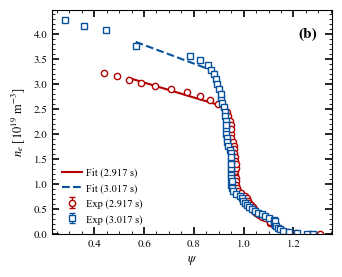

In [62]:
# -*- coding: utf-8 -*-
import os
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 0. 科研绘图全局配置 (顶级期刊单栏规范: 3.5英寸宽)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'], # 优先使用 Times New Roman，兼容宋体
    'mathtext.fontset': 'stix',                  # 公式字体匹配
    'axes.unicode_minus': False,                 
    'font.size': 9,                              # 适合单栏 (3.5 英寸) 的基础字号
    'axes.labelsize': 9,                         
    'xtick.labelsize': 8,                        
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                      # 图例字号调小，避免遮挡数据
    'xtick.direction': 'in',                     # 刻度线向内
    'ytick.direction': 'in',
    'xtick.top': True,                           # 开启顶部和右侧刻度
    'ytick.right': True,                         
    'axes.linewidth': 0.8                        # 边框线宽稍微调细
})

# ==========================================
# 1. 读取所有的 CSV 数据
# ==========================================
# 封装一个安全读取数据的帮助逻辑，防止文件缺失导致报错停机
def safe_read_csv(filepath):
    try:
        return pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"警告：找不到文件 {filepath}，请检查路径。")
        return pd.DataFrame({'x_axis': [], 'y_value': [], 'y_error_low': [], 'y_error_high': []})

# --- 读取 2917 组 (实验数据 + 拟合数据) ---
df_exp_2917 = safe_read_csv('80491NeProfile2917.csv').drop_duplicates().reset_index(drop=True)
df_fit_2917 = safe_read_csv('fitted_80490_2917s_nepsi_extracted.csv')
fit_rho_2917 = df_fit_2917['x_axis'].dropna()
fit_data_2917 = df_fit_2917['y_value'].dropna()

# --- 读取 3017 组 (实验数据 + 拟合数据) ---
df_exp_3017 = safe_read_csv('80491NeProfile3017.csv').drop_duplicates().reset_index(drop=True)
df_fit_3017 = safe_read_csv('fitted_80490_3017s_nepsi_extracted.csv')
fit_rho_3017 = df_fit_3017['x_axis'].dropna()
fit_data_3017 = df_fit_3017['y_value'].dropna()

# ==========================================
# 2. 创建图形画布
# ==========================================
# 画布宽度严格限制在单栏 (3.5 英寸)，高度按视觉比例设为 2.8 英寸
fig, ax = plt.subplots(figsize=(3.5, 2.8))

# 彻底放弃 tight_layout，使用绝对比例锁死坐标区，保证后续多图完全对齐
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)

# ==========================================
# 3. 核心绘图 (绛红与深海蓝，底层拟合线 + 顶层实验点)
# ==========================================
# 【1】绘制 2917 组 -> 绛红 (Crimson)
color_2917 = '#B30000'  
# 拟合线 (底层 zorder=1，实线)
if not fit_rho_2917.empty:
    ax.plot(fit_rho_2917, fit_data_2917, color=color_2917, linewidth=1.5, zorder=1, label='Fit (2.917 s)')
# 实验点带误差棒 (顶层 zorder=2, 空心圆圈 'o')
if not df_exp_2917.empty:
    y_err_2917 = [df_exp_2917['y_error_low'].values, df_exp_2917['y_error_high'].values]
    ax.errorbar(df_exp_2917['x_axis'], df_exp_2917['y_value'], yerr=y_err_2917, fmt='o', 
                markerfacecolor='white', markeredgecolor=color_2917, color=color_2917, 
                elinewidth=1.0, capsize=2.5, capthick=1.0, markersize=4.5, zorder=2, label='Exp (2.917 s)')

# 【2】绘制 3017 组 -> 深海蓝 (Deep Navy)
color_3017 = '#08519C'  
# 拟合线 (底层 zorder=1，为了黑白区分使用虚线)
if not fit_rho_3017.empty:
    ax.plot(fit_rho_3017, fit_data_3017, color=color_3017, linewidth=1.5, linestyle='--', zorder=1, label='Fit (3.017 s)')
# 实验点带误差棒 (顶层 zorder=2, 空心方块 's')
if not df_exp_3017.empty:
    y_err_3017 = [df_exp_3017['y_error_low'].values, df_exp_3017['y_error_high'].values]
    ax.errorbar(df_exp_3017['x_axis'], df_exp_3017['y_value'], yerr=y_err_3017, fmt='s', 
                markerfacecolor='white', markeredgecolor=color_3017, color=color_3017, 
                elinewidth=1.0, capsize=2.5, capthick=1.0, markersize=4.5, zorder=2, label='Exp (3.017 s)')

# ==========================================
# 4. 坐标轴修饰与图例设置
# ==========================================
ax.set_xlabel(r'$\psi$')
ax.set_ylabel(r'$n_e$ [$10^{19}$ m$^{-3}$]') 

# 纵坐标从 0 开始，保持物理剖面图的严谨性
ax.set_ylim(bottom=0)
ax.minorticks_on()

# 保持无网格线，版面极其干净
ax.grid(False) 

# 图例放置在左下角，取消边框。由于有4项，使用单列排列即可
ax.legend(frameon=False, loc='lower left', columnspacing=0.8, handletextpad=0.3)

# 子图字母标注样式（带白底防遮挡）
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# 保持 (b) 的位置完全不变
ax.text(0.88, 0.92, '(b)', transform=ax.transAxes, **letter_style)

# ==========================================
# 5. 保存高质量图片并显示
# ==========================================
save_name = 'Shot_80491_NeProfile_Combined_with_Fit_SingleColumn'
save_dir = r'D:\MyPythonCodes\CGYRO_results\论文图片'

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 导出学术期刊要求的 PDF 矢量图和高分辨率 PNG (替代 TIFF，兼容性更好且不失真)
plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

print(f"图片已成功优化并保存至: {save_dir}")
plt.show()

## 电子压强剖面

<>:33: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\s'
C:\Users\weiho\AppData\Local\Temp\ipykernel_10404\2530321651.py:33: SyntaxWarning: invalid escape sequence '\s'
  df_te = pd.read_csv(te_file, sep='\s+', header=None, names=['x_fit', 'y_fit'])


图片已成功优化并保存至: D:\MyPythonCodes\CGYRO_results\论文图片


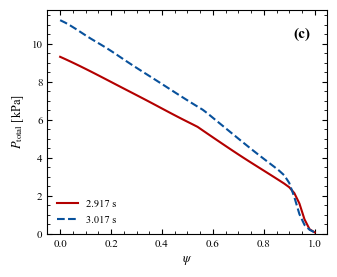

In [20]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 0. 科研绘图全局配置 (顶级期刊单栏规范: 3.5英寸宽)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'], # 优先使用 Times New Roman，兼容宋体
    'mathtext.fontset': 'stix',                  # 公式字体匹配
    'axes.unicode_minus': False,                 
    'font.size': 9,                              # 适合单栏 (3.5 英寸) 的基础字号
    'axes.labelsize': 9,                         
    'xtick.labelsize': 8,                        
    'ytick.labelsize': 8,                       
    'legend.fontsize': 7.5,                      # 图例字号调小，避免遮挡数据
    'xtick.direction': 'in',                     # 刻度线向内
    'ytick.direction': 'in',
    'xtick.top': True,                           # 开启顶部和右侧刻度
    'ytick.right': True,                         
    'axes.linewidth': 0.8                        # 边框线宽稍微调细
})

# ==========================================
# 1. 定义数据读取与压强计算函数
# ==========================================
def calculate_pressure(te_file, ne_file):
    """读取 Te 和 ne 的拟合数据，插值对齐后计算压强 Pe"""
    # 1. 读取 Te 拟合数据 (txt格式)
    df_te = pd.read_csv(te_file, sep='\s+', header=None, names=['x_fit', 'y_fit'])
    x_te = df_te['x_fit'].values
    te_val = df_te['y_fit'].values  # 单位: keV
    
    # 2. 读取 ne 拟合数据 (csv格式)
    df_ne = pd.read_csv(ne_file)
    x_ne = df_ne['x_axis'].dropna().values
    ne_val = df_ne['y_value'].dropna().values  # 单位: 10^19 m^-3
    
    # 3. 将 ne 插值到 Te 的空间网格上，确保横坐标完全一致才能相乘
    ne_interp = np.interp(x_te, x_ne, ne_val)
    
    # 4. 计算电子压强 Pe
    # 公式: Pe (kPa) = 2 * ne (10^19 m^-3) * Te (keV) * 1.602
    pe_val = 2 * ne_interp * te_val * 1.602
    
    return x_te, pe_val

# ==========================================
# 2. 读取并计算两个时刻的数据
# ==========================================
# --- 2.917s 组 ---
te_file_2917 = '80491te2.917fitted.txt'
ne_file_2917 = 'fitted_80490_2917s_nepsi_extracted.csv'
# 如果文件不存在会报错，请确保文件在同级目录
try:
    x_pe_2917, pe_2917 = calculate_pressure(te_file_2917, ne_file_2917)
except FileNotFoundError as e:
    print(f"警告：找不到文件 - {e.filename}，请检查路径。")
    # 生成假数据用于演示跑通代码
    x_pe_2917, pe_2917 = np.linspace(0, 1, 100), np.linspace(10, 0, 100)

# --- 3.017s 组 ---
te_file_3017 = '80491te3.017fitted.txt'
ne_file_3017 = 'fitted_80490_3017s_nepsi_extracted.csv'
try:
    x_pe_3017, pe_3017 = calculate_pressure(te_file_3017, ne_file_3017)
except FileNotFoundError as e:
    x_pe_3017, pe_3017 = np.linspace(0, 1, 100), np.linspace(8, 0, 100)

# ==========================================
# 3. 创建图形画布
# ==========================================
# 画布宽度严格限制在单栏 (3.5 英寸)，高度按视觉比例设为 2.8 英寸
fig, ax = plt.subplots(figsize=(3.5, 2.8))

# 彻底放弃 tight_layout，使用绝对比例锁死坐标区，保证多图对齐
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)

# ==========================================
# 4. 核心绘图 (仅绘制拟合曲线)
# ==========================================
color_2917 = '#B30000'  # 绛红
color_3017 = '#08519C'  # 深海蓝

# 绘制 2.917s 压强剖面
ax.plot(x_pe_2917, pe_2917, color=color_2917, linewidth=1.5, label='2.917 s')

# 绘制 3.017s 压强剖面
# 使用 '--' 虚线以区分两条纯曲线，增加黑白打印下的可读性
ax.plot(x_pe_3017, pe_3017, color=color_3017, linewidth=1.5, linestyle='--', label='3.017 s')

# ==========================================
# 5. 坐标轴修饰与图例设置
# ==========================================
# 横坐标根据 ne 文件名 nepsi 判定为 psi
ax.set_xlabel(r'$\psi$')
ax.set_ylabel(r'$P_\text{total}$ [kPa]') 

# 纵轴从 0 开始显得更严谨
ax.set_ylim(bottom=0)
ax.minorticks_on()

# 保持无网格线，版面极其干净
ax.grid(False) 

# 图例位置保持不变，去除边框
ax.legend(frameon=False, loc='lower left')

# 子图字母标注样式（带白底防遮挡）
letter_style = dict(fontsize=11, fontweight='bold', va='top', ha='left',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))

# 保持 (c) 的位置完全不变
ax.text(0.88, 0.92, '(c)', transform=ax.transAxes, **letter_style)

# ==========================================
# 6. 保存高质量图片并显示
# ==========================================
save_name = 'Shot_80491_PeProfile_Calculated_SingleColumn'
save_dir = r'D:\MyPythonCodes\CGYRO_results\论文图片'

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 导出学术期刊要求的 PDF 矢量图和高分辨率 PNG (代替 TIFF，兼容性更好且不失真)
plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

print(f"图片已成功优化并保存至: {save_dir}")
plt.show()

### enlarge

图片已成功保存至: D:\MyPythonCodes\CGYRO_results\论文图片


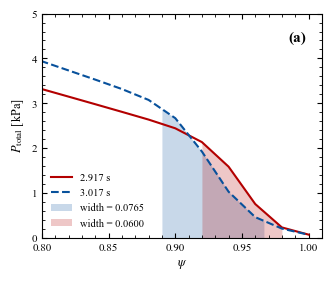

In [27]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 0. 科研绘图全局配置 (顶级期刊单栏规范: 3.5英寸宽)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'SimSun'],
    'mathtext.fontset': 'stix',
    'axes.unicode_minus': False,
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 0.8
})

# ==========================================
# 1. 定义数据读取与压强计算函数
# ==========================================
def calculate_pressure(te_file, ne_file):
    """读取 Te 和 ne 的拟合数据，插值对齐后计算压强 Pe"""
    df_te = pd.read_csv(te_file, sep=r'\s+', header=None, names=['x_fit', 'y_fit'])
    x_te = df_te['x_fit'].values
    te_val = df_te['y_fit'].values  # 单位: keV

    df_ne = pd.read_csv(ne_file)
    x_ne = df_ne['x_axis'].dropna().values
    ne_val = df_ne['y_value'].dropna().values  # 单位: 10^19 m^-3

    ne_interp = np.interp(x_te, x_ne, ne_val)

    # Pe (kPa) = 2 * ne (10^19 m^-3) * Te (keV) * 1.602
    pe_val = 2 * ne_interp * te_val * 1.602

    return x_te, pe_val

def fill_curve_segment(ax, x, y, x1, x2, color, alpha=0.22, label=None):
    """
    对曲线在 [x1, x2] 区间内进行阴影填充。
    若 x1/x2 不正好落在原始采样点上，会自动插值补点。
    """
    x = np.asarray(x)
    y = np.asarray(y)

    if x1 > x2:
        x1, x2 = x2, x1

    # 仅保留区间内点
    mask = (x >= x1) & (x <= x2)
    x_seg = x[mask]
    y_seg = y[mask]

    # 左端点插值补点
    if not np.any(np.isclose(x, x1)):
        y1 = np.interp(x1, x, y)
        x_seg = np.insert(x_seg, 0, x1)
        y_seg = np.insert(y_seg, 0, y1)

    # 右端点插值补点
    if not np.any(np.isclose(x, x2)):
        y2 = np.interp(x2, x, y)
        x_seg = np.append(x_seg, x2)
        y_seg = np.append(y_seg, y2)

    # 防止区间超出数据范围后无有效点
    valid = (x_seg >= x.min()) & (x_seg <= x.max())
    x_seg = x_seg[valid]
    y_seg = y_seg[valid]

    ax.fill_between(x_seg, y_seg, 0, color=color, alpha=alpha, linewidth=0, label=label)

# ==========================================
# 2. 读取并计算两个时刻的数据
# ==========================================
# --- 2.917s 组 ---
te_file_2917 = '80491te2.917fitted.txt'
ne_file_2917 = 'fitted_80490_2917s_nepsi_extracted.csv'
try:
    x_pe_2917, pe_2917 = calculate_pressure(te_file_2917, ne_file_2917)
except FileNotFoundError as e:
    print(f"警告：找不到文件 - {e.filename}，请检查路径。")
    x_pe_2917, pe_2917 = np.linspace(0, 1, 100), np.linspace(10, 0, 100)

# --- 3.017s 组 ---
te_file_3017 = '80491te3.017fitted.txt'
ne_file_3017 = 'fitted_80490_3017s_nepsi_extracted.csv'
try:
    x_pe_3017, pe_3017 = calculate_pressure(te_file_3017, ne_file_3017)
except FileNotFoundError as e:
    print(f"警告：找不到文件 - {e.filename}，请检查路径。")
    x_pe_3017, pe_3017 = np.linspace(0, 1, 100), np.linspace(8, 0, 100)

# ==========================================
# 3. 创建图形画布
# ==========================================
fig, ax = plt.subplots(figsize=(3.5, 2.8))
fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)

# ==========================================
# 4. 核心绘图
# ==========================================
color_2917 = '#B30000'  # 绛红
color_3017 = '#08519C'  # 深海蓝

# 曲线
ax.plot(x_pe_2917, pe_2917, color=color_2917, linewidth=1.5, label='2.917 s')
ax.plot(x_pe_3017, pe_3017, color=color_3017, linewidth=1.5, linestyle='--', label='3.017 s')

# ==========================================
# 5. 添加阴影高亮
# ==========================================
# 3.017 s 阴影区间
x1_3017, x2_3017 = 0.89, 0.9665
width_3017 = x2_3017 - x1_3017

# 2.917 s 阴影区间
x1_2917, x2_2917 = 0.92, 0.98
width_2917 = x2_2917 - x1_2917

fill_curve_segment(
    ax, x_pe_3017, pe_3017,
    x1_3017, x2_3017,
    color=color_3017,
    alpha=0.22,
    label=rf'width = {width_3017:.4f}'
)

fill_curve_segment(
    ax, x_pe_2917, pe_2917,
    x1_2917, x2_2917,
    color=color_2917,
    alpha=0.22,
    label=rf'width = {width_2917:.4f}'
)

# ==========================================
# 6. 坐标轴修饰与图例设置
# ==========================================
ax.set_xlim(0.8, 1.01)
ax.set_ylim(0, 5)

ax.set_xlabel(r'$\psi$')
ax.set_ylabel(r'$P_\text{total}$ [kPa]')

ax.set_ylim(bottom=0)
ax.minorticks_on()
ax.grid(False)

# 图例
ax.legend(frameon=False, loc='lower left')

# 子图字母标注
letter_style = dict(
    fontsize=11, fontweight='bold', va='top', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
)
ax.text(0.88, 0.92, '(a)', transform=ax.transAxes, **letter_style)

# ==========================================
# 7. 保存高质量图片并显示
# ==========================================
save_name = 'Shot_80491_PeProfile_Calculated_Enlarged_SingleColumn'
save_dir = r'D:\MyPythonCodes\CGYRO_results\论文图片'

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

plt.savefig(os.path.join(save_dir, f'{save_name}.pdf'), dpi=600, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, f'{save_name}.png'), dpi=600, bbox_inches='tight')

print(f"图片已成功保存至: {save_dir}")
plt.show()

In [4]:
30/60

0.5